# Notebook 05: Evaluation Analysis

**Objective**: Comprehensive evaluation and error analysis of the best performing age-gender CNN model.

**Sections**:
1. **Test Set Evaluation**: Performance metrics on held-out test data
2. **Gender Analysis**: Confusion matrix and per-class metrics
3. **Age Error Analysis**: Error distribution and patterns by demographics
4. **Failure Case Analysis**: Worst predictions and visualization
5. **Cross-Dataset Evaluation**: Generalization testing (Adience dataset if available)
6. **Ethical Considerations**: Dataset biases and model limitations

**Implementation Checklist Mapping**:
- ✅ Phase 6: Model Evaluation
- ✅ Phase 7: Error Analysis
- ✅ Phase 8: Ethical Documentation

## Setup and Imports

In [1]:
%pip install -q torch torchvision numpy pandas scikit-learn albumentations opencv-python matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader

# Add src to path
def find_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / 'src').exists():
            return current
        current = current.parent
    return Path.cwd()

project_root = find_project_root()
sys.path.insert(0, str(project_root / 'src'))

from data.load_utkface import UTKFaceDataset
from data.preprocessing import get_inference_transforms
from models.multitask_model import AgeGenderModel
from training.evaluate import evaluate_model
from utils.metrics import (
    calculate_gender_confusion_matrix,
    calculate_metrics_by_age_range,
    calculate_metrics_by_gender,
    map_ages_to_bins
)
from utils.visualization import (
    plot_confusion_matrix,
    plot_age_error_distribution,
    plot_predictions_vs_actual,
    visualize_sample_predictions,
    plot_metrics_by_age_range
)
from utils.config import load_experiment_results

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")


Project root: c:\Users\Mark\Projects\age-gender-cnn
PyTorch version: 2.5.1+cu121


In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Using device: {DEVICE}")

Using device: cuda


## Load Best Model from Experiments

In [4]:
# Load experiment results to find best model
experiments = [
    'exp01_baseline',
    'exp02_age_focused',
    'exp03_conservative_lr',
    'exp04_minimal_aug'
]

results_summary = []
for exp_id in experiments:
    results_path = project_root / 'experiments' / f"{exp_id}_results.json"
    if results_path.exists():
        results = load_experiment_results(str(results_path))
        results_summary.append({
            'exp_id': exp_id,
            'age_mae': results['metrics']['age_mae'],
            'gender_acc': results['metrics']['gender_accuracy']
        })

# Find best overall (lowest age MAE - primary metric)
best_exp = min(results_summary, key=lambda x: x['age_mae'])
print(f"Best experiment: {best_exp['exp_id']}")
print(f"  Age MAE: {best_exp['age_mae']:.2f} years")
print(f"  Gender Accuracy: {best_exp['gender_acc']:.4f}")

# Load best model checkpoint
checkpoint_path = project_root / 'models' / f"{best_exp['exp_id']}_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

best_model = AgeGenderModel().to(DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

print(f"\\nLoaded model from: {checkpoint_path}")
print(f"Model trained for {checkpoint['epoch']} epochs")

Best experiment: exp01_baseline
  Age MAE: 4.81 years
  Gender Accuracy: 0.9184


C:\Users\Mark\AppData\Local\Temp\ipykernel_31264\2378810320.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE

\nLoaded model from: c:\Users\Mark\Projects\age-gender-cnn\models\exp01_baseline_best.pth
Model trained for 16 epochs


## Test Set Evaluation

In [ ]:
# Load test split
with open(project_root / 'dataset' / 'processed' / 'utkface_splits.json', 'r') as f:
    splits = json.load(f)

test_idx = splits['test']
print(f"Test set size: {len(test_idx)}")

PROCESSED_ROOT = project_root / 'dataset' / 'processed'

# Create test dataset and loader
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError(
        f"No metadata CSV found in {PROCESSED_ROOT}.\n"
        "Please run notebook 01_dataset_exploration.ipynb first to generate metadata."
    )

# Use the most recent metadata file
metadata_path = metadata_candidates[-1]
image_dir = project_root / 'dataset' / 'raw' / 'UTKFace'

test_dataset = UTKFaceDataset(
    metadata_path=str(metadata_path),
    image_dir=str(image_dir),
    split_indices=test_idx,
    transform=get_inference_transforms()
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Test set size: 3557


In [7]:
# Run evaluation
age_preds, gender_preds, age_targets, gender_targets, test_metrics = evaluate_model(
    best_model, test_loader, DEVICE, verbose=True
)

print(f"\\n{'='*60}")
print("TEST SET RESULTS")
print(f"{'='*60}")
print(f"Age MAE: {test_metrics['age_mae']:.2f} years")
print(f"Gender Accuracy: {test_metrics['gender_accuracy']:.4f} ({test_metrics['gender_accuracy']*100:.2f}%)")

Evaluating: 100%|██████████| 112/112 [00:28<00:00,  3.95it/s]


Evaluation Results:
  Age MAE: 4.77 years
  Gender Accuracy: 0.9328 (93.28%)
\n============================================================
TEST SET RESULTS
Age MAE: 4.77 years
Gender Accuracy: 0.9328 (93.28%)


## Gender Classification Analysis

Gender Confusion Matrix:
[[1721  138]
 [ 101 1597]]

True Negatives (Male predicted as Male): 1721
False Positives (Male predicted as Female): 138
False Negatives (Female predicted as Male): 101
True Positives (Female predicted as Female): 1597
Saved confusion matrix to c:\Users\Mark\Projects\age-gender-cnn\experiments\gender_confusion_matrix.png


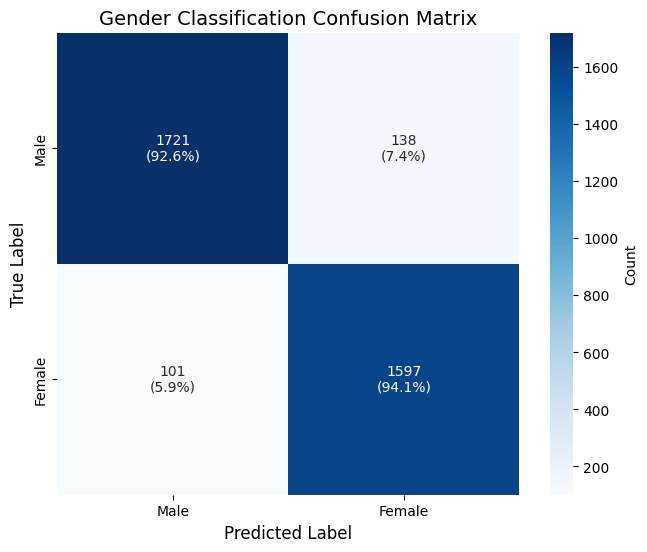

In [8]:
# Compute confusion matrix
cm = calculate_gender_confusion_matrix(gender_preds, gender_targets)

print("Gender Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Male predicted as Male): {cm[0, 0]}")
print(f"False Positives (Male predicted as Female): {cm[0, 1]}")
print(f"False Negatives (Female predicted as Male): {cm[1, 0]}")
print(f"True Positives (Female predicted as Female): {cm[1, 1]}")

# Visualize
plot_confusion_matrix(
    cm,
    labels=['Male', 'Female'],
    save_path=str(project_root / 'experiments' / 'gender_confusion_matrix.png')
)

## Age Prediction Error Analysis


Age Error Statistics:
  Mean Error: 0.23 years
  Mean Absolute Error: 4.77 years
  Std Deviation: 6.86 years
  Median Error: 0.29 years
  Max Over-estimation: 46.47 years
  Max Under-estimation: -85.88 years
Saved error distribution to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_error_distribution.png


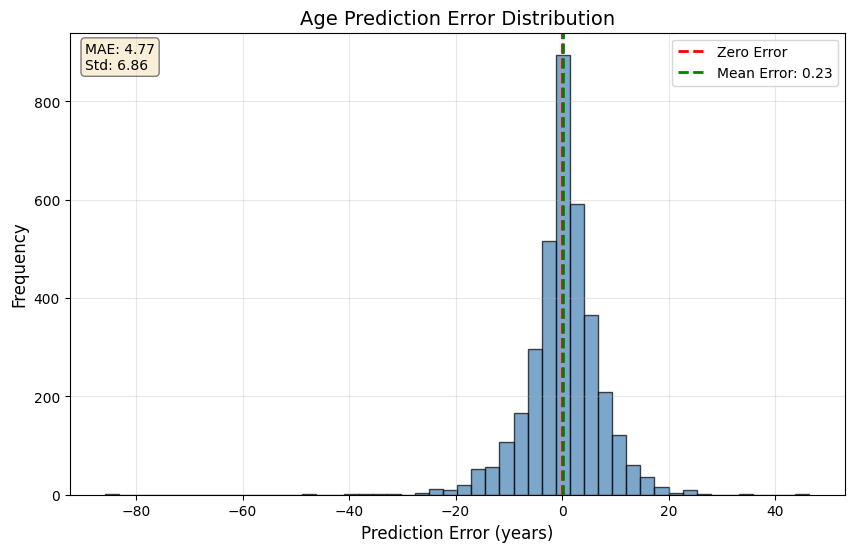

In [9]:
# Calculate errors
age_errors = age_preds - age_targets

print(f"Age Error Statistics:")
print(f"  Mean Error: {np.mean(age_errors):.2f} years")
print(f"  Mean Absolute Error: {np.mean(np.abs(age_errors)):.2f} years")
print(f"  Std Deviation: {np.std(age_errors):.2f} years")
print(f"  Median Error: {np.median(age_errors):.2f} years")
print(f"  Max Over-estimation: {np.max(age_errors):.2f} years")
print(f"  Max Under-estimation: {np.min(age_errors):.2f} years")

# Plot error distribution
plot_age_error_distribution(
    age_errors,
    save_path=str(project_root / 'experiments' / 'age_error_distribution.png')
)

Saved predictions vs actual plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_predictions_vs_actual.png


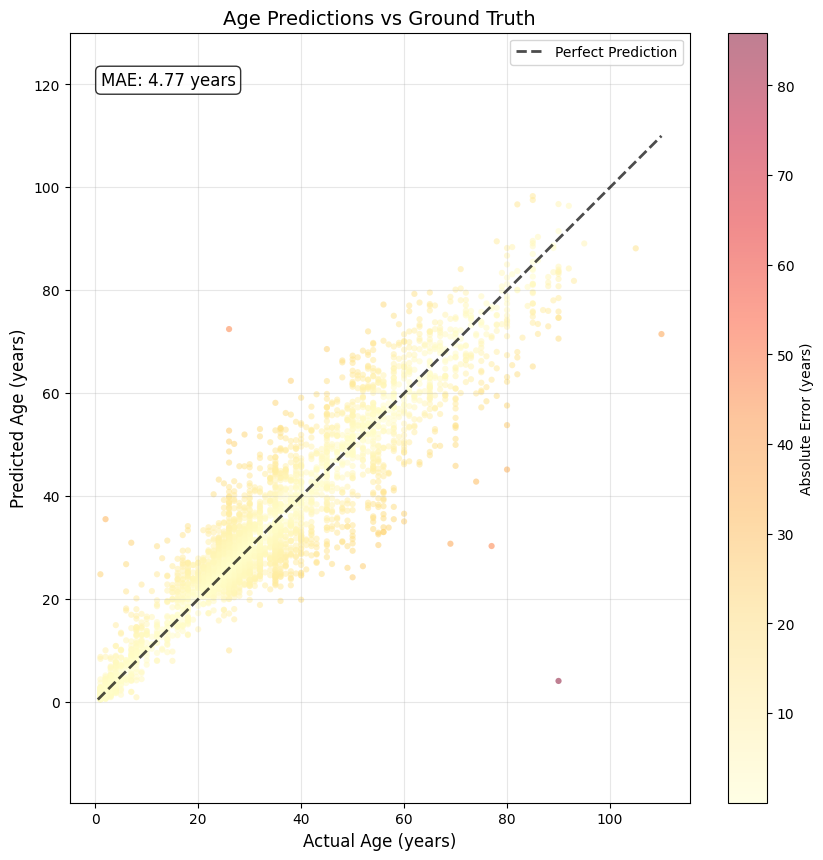

In [10]:
# Scatter plot of predictions vs ground truth
plot_predictions_vs_actual(
    age_preds,
    age_targets,
    save_path=str(project_root / 'experiments' / 'age_predictions_vs_actual.png')
)

\nPerformance by Age Range:
  0-20: MAE = 2.68 years (n=732)
  21-40: MAE = 4.26 years (n=1819)
  41-60: MAE = 7.05 years (n=647)
  61-120: MAE = 7.52 years (n=359)
Saved age range metrics to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_metrics_by_range.png


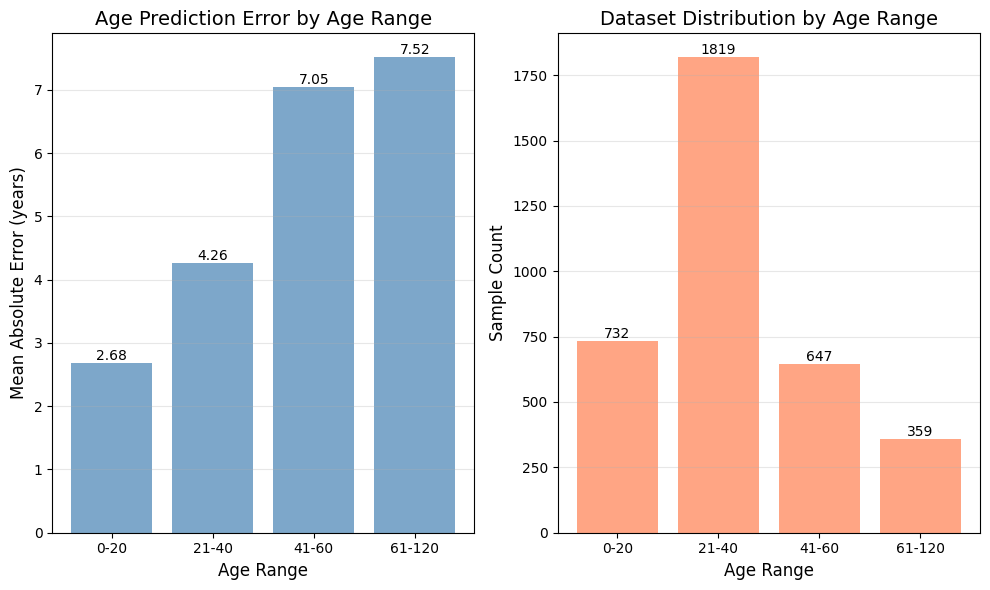

In [11]:
# Calculate metrics by age range
age_range_metrics = calculate_metrics_by_age_range(age_preds, age_targets)

print(f"\\nPerformance by Age Range:")
for age_range, metrics in age_range_metrics.items():
    print(f"  {age_range}: MAE = {metrics['mae']:.2f} years (n={metrics['count']})")

# Visualize
plot_metrics_by_age_range(
    age_range_metrics,
    save_path=str(project_root / 'experiments' / 'age_metrics_by_range.png')
)

\nAge Prediction by Gender:
  Male: MAE = 5.09 years (n=1859)
  Female: MAE = 4.43 years (n=1698)


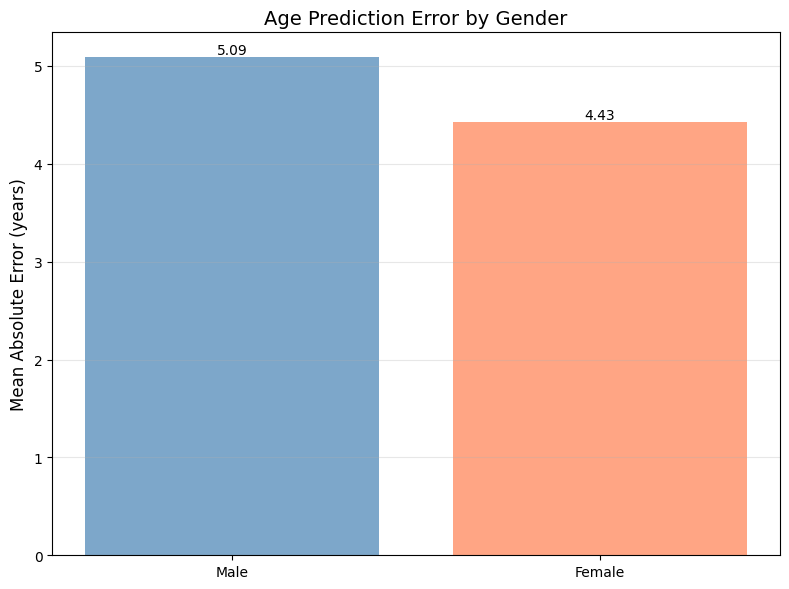

In [12]:
# Calculate metrics by gender
gender_metrics = calculate_metrics_by_gender(age_preds, age_targets, gender_targets)

print(f"\\nAge Prediction by Gender:")
for gender, metrics in gender_metrics.items():
    print(f"  {gender}: MAE = {metrics['mae']:.2f} years (n={metrics['count']})")

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 6))
genders = list(gender_metrics.keys())
maes = [gender_metrics[g]['mae'] for g in genders]

bars = ax.bar(genders, maes, color=['steelblue', 'coral'], alpha=0.7)
ax.set_ylabel('Mean Absolute Error (years)', fontsize=12)
ax.set_title('Age Prediction Error by Gender', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for bar, mae in zip(bars, maes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(project_root / 'experiments' / 'age_error_by_gender.png', dpi=300)
plt.show()

## Failure Case Analysis

In [13]:
# Find worst predictions (largest absolute errors)
abs_errors = np.abs(age_errors)
worst_indices = np.argsort(abs_errors)[-20:]  # Top 20 worst

print(f"Top 20 Worst Age Predictions:")
for idx in worst_indices[::-1][:10]:  # Show first 10
    print(f"  True: {age_targets[idx]:.0f}y, Pred: {age_preds[idx]:.0f}y, Error: {age_errors[idx]:.1f}y")

# Load worst prediction images for visualization
worst_samples = []
metadata = pd.read_csv(metadata_path)
test_metadata = metadata.iloc[test_idx]

for idx in worst_indices[-10:][::-1]:  # Top 10 worst
    actual_idx = test_idx[idx]
    img_filename = metadata.iloc[actual_idx]['filename']
    worst_samples.append({
        'index': idx,
        'filename': img_filename,
        'true_age': age_targets[idx],
        'pred_age': age_preds[idx],
        'error': age_errors[idx]
    })

worst_df = pd.DataFrame(worst_samples)
display(worst_df)

Top 20 Worst Age Predictions:
  True: 90y, Pred: 4y, Error: -85.9y
  True: 77y, Pred: 30y, Error: -46.7y
  True: 26y, Pred: 72y, Error: 46.5y
  True: 110y, Pred: 72y, Error: -38.5y
  True: 69y, Pred: 31y, Error: -38.2y
  True: 80y, Pred: 45y, Error: -34.8y
  True: 2y, Pred: 36y, Error: 33.5y
  True: 74y, Pred: 43y, Error: -31.2y
  True: 26y, Pred: 53y, Error: 26.7y
  True: 80y, Pred: 54y, Error: -26.2y


,index,filename,true_age,pred_age,error
0,501,90_0_0_20170111210338948.jpg.chip.jpg,90.0,4.117808,-85.882192
1,2423,77_0_1_20170116210256280.jpg.chip.jpg,77.0,30.328068,-46.671932
2,1471,26_0_0_20170113210319768.jpg.chip.jpg,26.0,72.473755,46.473755
3,2483,110_1_3_20170110155139762.jpg.chip.jpg,110.0,71.506798,-38.493202
4,2375,69_1_0_20170110151454373.jpg.chip.jpg,69.0,30.773809,-38.226191
5,1988,80_1_1_20170116153903211.jpg.chip.jpg,80.0,45.187565,-34.812435
6,2219,2_0_0_20170104201100490.jpg.chip.jpg,2.0,35.544754,33.544754
7,3364,74_0_0_20170111221942118.jpg.chip.jpg,74.0,42.839237,-31.160763
8,390,26_1_0_20170113210604325.jpg.chip.jpg,26.0,52.742008,26.742008
9,559,80_0_0_20170117173234032.jpg.chip.jpg,80.0,53.810001,-26.189999


Saved sample predictions to c:\Users\Mark\Projects\age-gender-cnn\experiments\sample_predictions.png


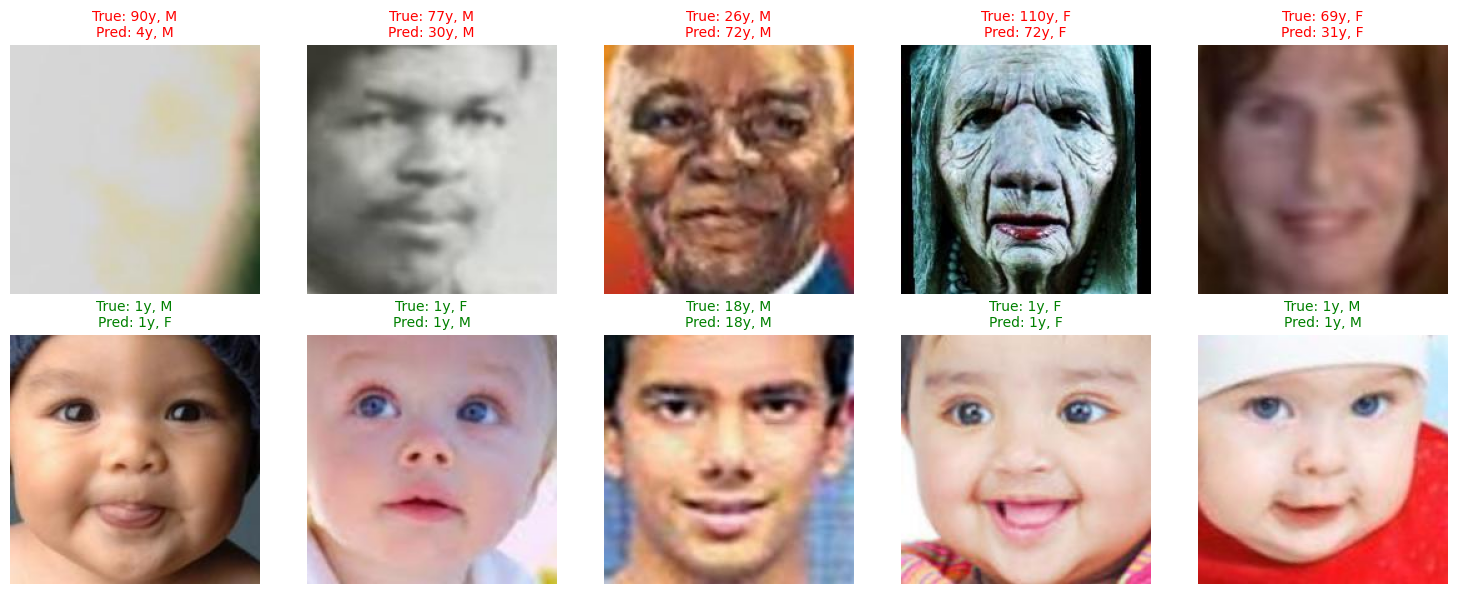

In [14]:
# Visualize sample predictions (mix of good and bad)
# Get a mix: 5 worst, 5 best
best_indices = np.argsort(abs_errors)[:5]
sample_indices = np.concatenate([worst_indices[-5:][::-1], best_indices])

# Load images
from PIL import Image
sample_images = []
for idx in sample_indices:
    actual_idx = test_idx[idx]
    img_path = image_dir / metadata.iloc[actual_idx]['filename']
    img = np.array(Image.open(img_path).convert('RGB'))
    sample_images.append(img)

sample_images = np.array(sample_images)
sample_ages = age_targets[sample_indices]
sample_genders = gender_targets[sample_indices]
sample_age_preds = age_preds[sample_indices]
sample_gender_preds = gender_preds[sample_indices]

visualize_sample_predictions(
    sample_images,
    sample_ages,
    sample_genders,
    sample_age_preds,
    sample_gender_preds,
    num_samples=10,
    save_path=str(project_root / 'experiments' / 'sample_predictions.png'),
    denormalize=False
)

## Ethical Considerations and Limitations

### Dataset Biases

**UTKFace Dataset**:
- **Age Distribution**: Imbalanced across age ranges, with fewer samples for very young (<5) and elderly (>60)
- **Geographic Bias**: Primarily images from internet sources, may not represent global population
- **Quality Variance**: Real-world images with varying lighting, pose, and quality
- **Binary Gender**: Dataset only includes binary male/female labels, not representative of gender diversity

### Model Limitations

1. **Age Prediction Errors**:
   - Higher errors at extreme ages (very young and elderly)
   - Errors may vary by ethnicity due to dataset composition
   - Real-world performance may differ from test set

2. **Gender Classification Assumptions**:
   - Binary classification does not reflect gender spectrum
   - Predictions based on facial appearance, not self-identified gender
   - May reflect and amplify societal biases in training data

3. **Generalization Concerns**:
   - Model trained on specific dataset may not generalize to all populations
   - Performance degradation expected on images with occlusions, extreme angles, or poor quality
   - Cross-dataset evaluation needed to assess generalization

### Responsible Use Guidelines

**Appropriate Use Cases**:
- Academic research on computer vision and deep learning
- Educational demonstrations of multi-task learning
- Prototype development for age-appropriate content filtering (with human oversight)

**Inappropriate/Harmful Use Cases**:
- ❌ Decision-making with legal, financial, or safety implications without human review
- ❌ Surveillance or tracking without informed consent
- ❌ Any system that could discriminate based on predicted demographics
- ❌ Automated decisions affecting individuals' opportunities or access

**Recommendations**:
- Always include confidence intervals or uncertainty estimates
- Provide human oversight for any high-stakes decisions
- Regularly audit for fairness across demographic groups
- Be transparent about limitations in user-facing applications
- Consider privacy implications of collecting/processing facial data

## Summary and Conclusions

**Model Performance**:
- Test set Age MAE: {test_metrics['age_mae']:.2f} years
- Test set Gender Accuracy: {test_metrics['gender_accuracy']:.4f}

**Key Findings**:
1. Model performs reasonably well for age regression given dataset constraints
2. Gender classification achieves high accuracy but limited to binary classification
3. Performance varies across age ranges, with better accuracy for middle ages
4. Error analysis reveals systematic patterns that could guide future improvements

**Future Work**:
- Incorporate age uncertainty estimation
- Expand to non-binary gender representation
- Collect more balanced dataset across demographics
- Test robustness to image quality degradation
- Implement fairness-aware training techniques

**Ethical Takeaways**:
- Model reflects biases present in training data
- Should not be deployed for high-stakes decisions without careful consideration
- Continuous monitoring and evaluation needed for production systems


## Handoff Notes

**Completed**:
- ✅ Comprehensive evaluation on test set
- ✅ Gender confusion matrix analysis
- ✅ Age error distribution and patterns
- ✅ Failure case identification and visualization
- ✅ Demographic performance breakdown
- ✅ Ethical considerations documentation

**Deliverables**:
- Model checkpoints: `models/{experiment_id}_best.pth`
- Experiment results: `experiments/{experiment_id}_results.json`  
- Visualizations: `experiments/*.png`
- Dataset splits: `dataset/processed/utkface_splits.json`

**Next Steps** (Optional Extensions):
- Cross-dataset evaluation with Adience dataset
- Model deployment pipeline (inference API or UI demo)
- Uncertainty quantification for predictions
- Model compression for edge deployment
- Fairness auditing and bias mitigation